In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [68]:
df = pd.read_csv('titanic_train.csv')
de = pd.read_csv('titanic_test.csv')

In [69]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [70]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['AgeGroup'] = pd.cut (
    df['Age'],
    bins = [ 0, 12, 18, 60, float('inf')],
    labels = [ 'child', 'teen', 'adult', 'senior'],
    right = False
)
print( df[['Age', 'AgeGroup']] )

      Age AgeGroup
0    22.0    adult
1    38.0    adult
2    26.0    adult
3    35.0    adult
4    35.0    adult
..    ...      ...
886  27.0    adult
887  19.0    adult
888  28.0    adult
889  26.0    adult
890  32.0    adult

[891 rows x 2 columns]


In [71]:
overall_survival_rate = df['Survived'].mean() * 100
print (f'The overal survived rate is : {overall_survival_rate : .2f}%')

The overal survived rate is :  38.38%


In [72]:
overall_survival_rate_by_sex = df.groupby('Sex')['Survived'].mean() * 100
result = print (round(overall_survival_rate_by_sex,2))

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


In [73]:
overall_survival_rate_by_sex = df.groupby('Pclass')['Survived'].mean() * 100
result = print (round(overall_survival_rate_by_sex,2))

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [74]:
group_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100
print(round(group_by_age,2))

AgeGroup
child     57.35
teen      48.89
adult     36.44
senior    26.92
Name: Survived, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_14764\567773450.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_by_age = df.groupby('AgeGroup')['Survived'].mean() * 100


In [75]:
df.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked         object
AgeGroup       category
dtype: object

In [76]:
de.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [77]:
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()
corr_matrix['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.064910
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

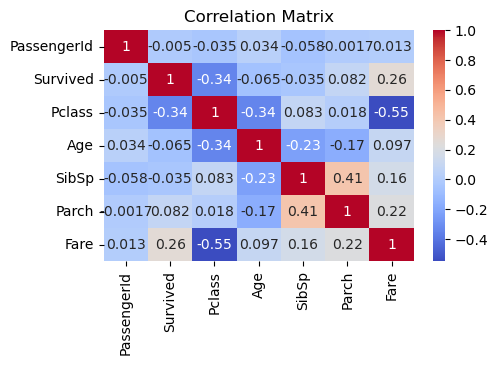

In [78]:
corr_matrix['Survived'].sort_values(ascending = False)
plt.figure(figsize=(5,3))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [79]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
AgeGroup         0
dtype: int64

In [80]:
len(df)

891

In [81]:
df['Age'].isnull().sum()

np.int64(0)

In [82]:
df['Cabin'].isnull().sum()

np.int64(687)

In [83]:
df['Embarked'].mode

<bound method Series.mode of 0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object>

In [84]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode(0)[0])

In [85]:
df['Embarked'].isnull().sum()

np.int64(0)

In [87]:
df = df.drop('Cabin', axis = 1)

In [88]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Embarked',
 'AgeGroup']

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    object  
 11  AgeGroup     891 non-null    category
dtypes: category(1), float64(2), int64(5), object(4)
memory usage: 77.8+ KB


In [90]:
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    int64   
 2   Sex       891 non-null    object  
 3   Age       891 non-null    float64 
 4   SibSp     891 non-null    int64   
 5   Parch     891 non-null    int64   
 6   Fare      891 non-null    float64 
 7   Embarked  891 non-null    object  
 8   AgeGroup  891 non-null    category
dtypes: category(1), float64(2), int64(4), object(2)
memory usage: 56.9+ KB


In [92]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = ( df['FamilySize'] == 1).astype(int)

In [93]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [94]:
df['Sex'] = df['Sex'].map({
    'male' : 1,
    'female' : 0,
})

In [95]:
df['Sex'].unique()

array([1, 0])

In [96]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [97]:
df['Embarked'] = df['Embarked'].map({
    'S' : 0,
    'C' : 1,
    'Q' : 2
})

In [98]:
df['Embarked'].unique()

array([0, 1, 2])

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 non-null    int64   
 1   Pclass      891 non-null    int64   
 2   Sex         891 non-null    int64   
 3   Age         891 non-null    float64 
 4   SibSp       891 non-null    int64   
 5   Parch       891 non-null    int64   
 6   Fare        891 non-null    float64 
 7   Embarked    891 non-null    int64   
 8   AgeGroup    891 non-null    category
 9   FamilySize  891 non-null    int64   
 10  IsAlone     891 non-null    int64   
dtypes: category(1), float64(2), int64(8)
memory usage: 70.8 KB


In [136]:
X = df.drop('Survived', axis = 1)
y = df['Survived']

In [137]:
print(X.shape)
print(y.shape)

(891, 10)
(891,)


In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42, stratify = y)

In [134]:
print(X_train.shape)
print(X_test.shape)

(712, 10)
(179, 10)


In [122]:
df['AgeGroup'] = df['AgeGroup'].map({
    'child' : 0,
    'teen' : 1,
    'adult' : 2,
    'senior' : 3,
})
df['AgeGroup'].unique()

array([nan])

In [126]:
df = df.drop('AgeGroup', axis = 1)

In [127]:
'AgeGroup' in df.columns

False

In [128]:
df["Age"].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

In [139]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['AgeGroup'] = pd.cut (
    df['Age'],
    bins = [ 0, 12, 18, 60, 100],
    labels = [ 'child', 'teen', 'adult', 'senior'],
    right = False
)
print( df[['Age', 'AgeGroup']] )

      Age AgeGroup
0    22.0    adult
1    38.0    adult
2    26.0    adult
3    35.0    adult
4    35.0    adult
..    ...      ...
886  27.0    adult
887  19.0    adult
888  28.0    adult
889  26.0    adult
890  32.0    adult

[891 rows x 2 columns]


In [140]:
df["AgeGroup"] = df["AgeGroup"].cat.codes

In [141]:
df['AgeGroup']

0    2
Name: AgeGroup, dtype: int8

In [142]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [143]:
print(X.dtypes)

Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
AgeGroup         int8
dtype: object


In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [145]:
print(X_train.shape)
print(X_test.shape)

(712, 10)
(179, 10)


In [147]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [160]:
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred) * 100
print(f'Accuracy : {lr_acc:.2f}')

Accuracy : 82.68


In [164]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred) * 100
print(f"Accuracy : {rf_acc:.2f}")

Accuracy : 81.56


In [166]:
gb = GradientBoostingClassifier( random_state = 42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred) * 100
print(f"Accuracy : {gb_acc:.2f}")

Accuracy : 80.45


In [167]:
lr_f1 = f1_score(y_test, lr_pred)
rf_f1 = f1_score(y_test, rf_pred)
gb_f1 = f1_score(y_test, gb_pred)

In [170]:
print(f"Logistic Regression f1 score : {lr_f1:.2f}")
print(f"Random Forest f1 score       : {rf_f1:.2f}")
print(f"Gradient Boosting f1 score   : {gb_f1:.2f}")

Logistic Regression f1 score : 0.76
Random Forest f1 score       : 0.76
Gradient Boosting f1 score   : 0.72


In [171]:
lr_auc = roc_auc_score(
    y_test,
    lr.predict_proba(X_test)[:,1]
)

rf_auc = roc_auc_score(
    y_test,
    rf.predict_proba(X_test)[:,1]
)

gb_auc = roc_auc_score(
    y_test,
    gb.predict_proba(X_test)[:,1]
)

In [172]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_acc,
        rf_acc,
        gb_acc
    ],
    "F1": [
        lr_f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        gb_auc
    ]
})

print(results)

                 Model   Accuracy        F1   ROC-AUC
0  Logistic Regression  82.681564  0.755906  0.851910
1        Random Forest  81.564246  0.759124  0.837220
2    Gradient Boosting  80.446927  0.720000  0.820883


In [193]:
scores = cross_val_score( lr, X, y, cv = 5, scoring = 'accuracy')
print (scores)

[0.77094972 0.79213483 0.79213483 0.78651685 0.84269663]


In [194]:
print("Mean Accuracy:", round( scores.mean() * 100, 2))

Mean Accuracy: 79.69


In [201]:
# Combination 1: Stronger Regularization
lr1 = LogisticRegression(
    C=0.1,
    max_iter=1000
)

score1 = cross_val_score(
    lr1,
    X,
    y,
    cv=5,
    scoring='accuracy'
).mean() * 100

# Combination 2: Default
lr2 = LogisticRegression(
    C=1,
    max_iter=1000
)

score2 = cross_val_score(
    lr2,
    X,
    y,
    cv=5,
    scoring='accuracy'
).mean() * 100

# Combination 3: Weaker Regularization
lr3 = LogisticRegression(
    C=10,
    max_iter=1000
)

score3 = cross_val_score(
    lr3,
    X,
    y,
    cv=5,
  scoring='accuracy'
).mean() * 100

# Compare Results
results_cv = pd.DataFrame({
    'C': [0.1, 1, 10],
    'Mean CV Accuracy': [score1, score2, score3]
})

print(results_cv)

      C  Mean CV Accuracy
0   0.1         80.362815
1   1.0         79.688657
2  10.0         79.464566


In [202]:
print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'FamilySize', 'IsAlone', 'AgeGroup'],
      dtype='object')


In [204]:
# Testing the model predictions
# Three predictions
    # 1- Young female, first class
        # -Female
        #1st Class
        #Age 25
        #High Fare
        #Traveling alone
    # 2- Older male, third class
        #Male
        #3rd Class
        #Age 60
        #Low Fare
        #Traveling alone   
    # 3- Child in second class
        #Child
        #2nd Class
        #Traveling with family


# We need to encode the category and object into numeric number so that it's understood by the model
# The encoding is done as per the preprocessing step

In [205]:
new_passengers = pd.DataFrame([
    [1, 1, 25, 0, 0, 80, 0, 1, 1, 2],   # Example 1
    [3, 0, 60, 0, 0, 8, 0, 1, 1, 3],    # Example 2
    [2, 0, 10, 1, 1, 20, 0, 3, 0, 0]    # Example 3
], columns=X.columns)

In [210]:
# Since from the 5 fold cross-validation Gradient Boosting accuracy was highest
predictions = gb.predict(new_passengers)

print(predictions)

[0 0 1]


In [216]:
probabilities = np.round (gb.predict_proba(new_passengers) * 100,2)

print(probabilities)

[[75.92 24.08]
 [73.83 26.17]
 [24.16 75.84]]


In [217]:
# Final Result

In [218]:
# Predictions
predictions = gb.predict(new_passengers)

# Probabilities
probabilities = gb.predict_proba(new_passengers)

# Display results
for i in range(len(new_passengers)):
    print(f"Passenger {i+1}")
    print(f"Prediction: {'Survived' if predictions[i] == 1 else 'Did Not Survive'}")
    print(f"Probability of Survival: {probabilities[i][1]*100:.2f}%")
    print(f"Probability of Death: {probabilities[i][0]*100:.2f}%")
    print("-"*40)

Passenger 1
Prediction: Did Not Survive
Probability of Survival: 24.08%
Probability of Death: 75.92%
----------------------------------------
Passenger 2
Prediction: Did Not Survive
Probability of Survival: 26.17%
Probability of Death: 73.83%
----------------------------------------
Passenger 3
Prediction: Survived
Probability of Survival: 75.84%
Probability of Death: 24.16%
----------------------------------------


In [219]:
results = pd.DataFrame({
    "Prediction": ["Survived" if p == 1 else "Did Not Survive"
                   for p in predictions],
    "Survival Probability (%)": probabilities[:,1] * 100,
    "Death Probability (%)": probabilities[:,0] * 100
})

print(results)

        Prediction  Survival Probability (%)  Death Probability (%)
0  Did Not Survive                 24.079579              75.920421
1  Did Not Survive                 26.174123              73.825877
2         Survived                 75.842693              24.157307
